Compression ratio for k=5: 0.0181, Error: 0.3325
Compression ratio for k=20: 0.0725, Error: 0.1818
Compression ratio for k=50: 0.1812, Error: 0.1032
Compression ratio for k=100: 0.3623, Error: 0.0591
Compression ratio for k=200: 0.7246, Error: 0.0253

Theoretical vs Actual Error for Channel R:
k=5: theory 0.3435 vs actual 0.3435
k=20: theory 0.1796 vs actual 0.1796
k=50: theory 0.0990 vs actual 0.0990
k=100: theory 0.0564 vs actual 0.0564
k=200: theory 0.0242 vs actual 0.0242


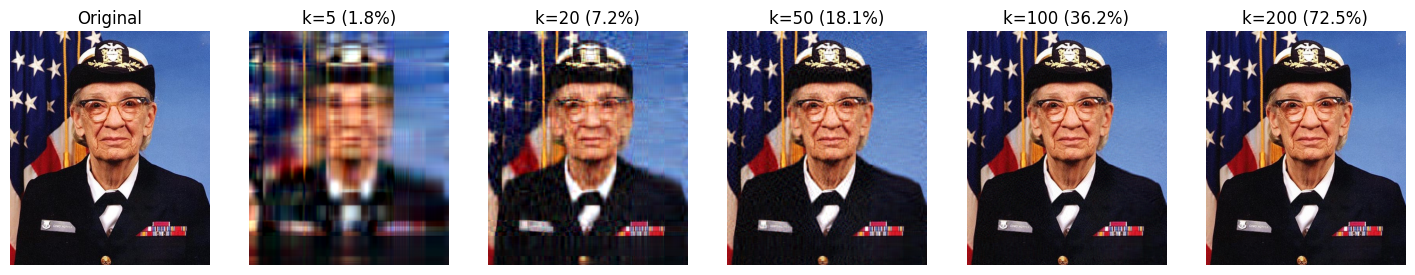

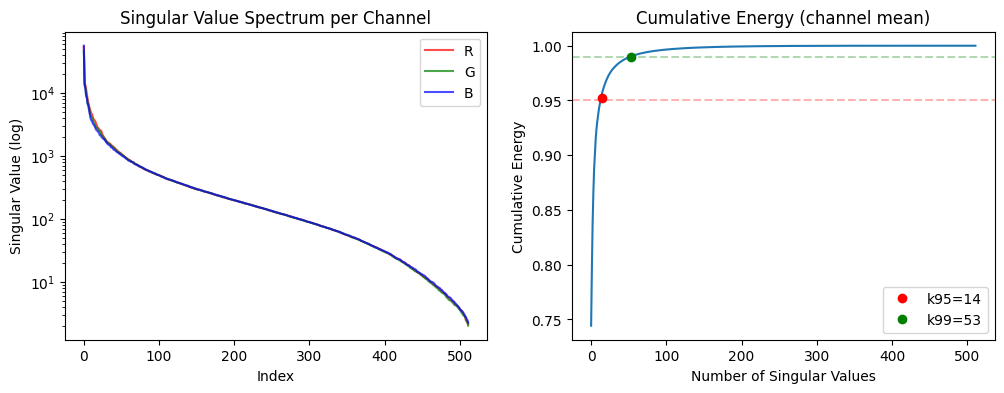

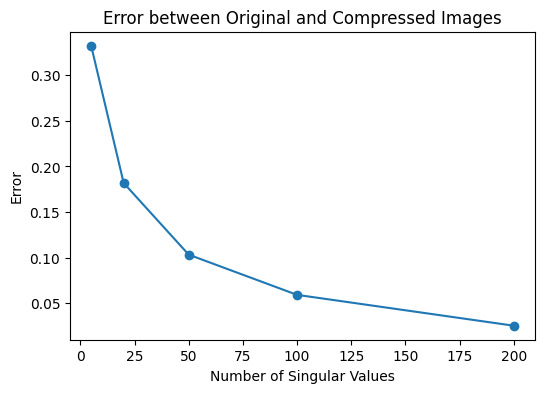

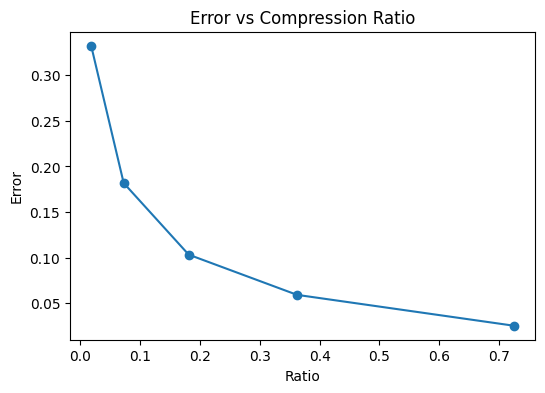

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cbook as cbook
with cbook.get_sample_data('grace_hopper.jpg') as f:
    img = plt.imread(f)

ks = [5, 20, 50, 100, 200]
errors = []
ratios = []

compress = lambda U, s, Vt, k: U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]

def compressed_ratio(m, n, k):
    return k * (m + n + 1) / (m * n)

def cumulative_energy(s):
    return np.cumsum(s**2) / np.sum(s**2)

def error(original, compressed):
    return np.linalg.norm(original - compressed) / np.linalg.norm(original)

compressed_imgs = []

if img.ndim == 3:
    # split the image into its three channels
    imgR =img[..., 0]
    imgG = img[..., 1]
    imgB = img[..., 2]
    svd_per_channel = []

    for ch in [imgR, imgG, imgB]:
        svd_per_channel.append(np.linalg.svd(ch, full_matrices=False))

    for k in ks:
        channels = []
        for U, s, Vt in svd_per_channel:
            channels.append(compress(U, s, Vt, k))
        compressed_img = np.stack(channels, axis=-1)
        compressed_imgs.append(compressed_img)
        errors.append(error(img, compressed_img))
        ratios.append(compressed_ratio(*img.shape[:2], k))
        print(f"Compression ratio for k={k}: {ratios[-1]:.4f}, Error: {errors[-1]:.4f}")

else:
    for k in ks:
        U, s, Vt = np.linalg.svd(img, full_matrices=False)
        compressed_img = compress(U, s, Vt, k)
        compressed_imgs.append(compressed_img)
        errors.append(error(img, compressed_img))
        ratios.append(compressed_ratio(*img.shape[:2], k))
        print(f"Compression ratio for k={k}: {ratios[-1]:.4f}, Error: {errors[-1]:.4f}")

# verify the theoretical error bound for channel R
U, s_ch, Vt = svd_per_channel[0]
print("\nTheoretical vs Actual Error for Channel R:")
for k in ks:
    theory = np.sqrt(np.sum(s_ch[k:]**2)) / np.linalg.norm(imgR)
    actual = error(imgR, compress(U, s_ch, Vt, k))
    print(f"k={k}: theory {theory:.4f} vs actual {actual:.4f}")

# ===========Visualization==========
# visualize the original and compressed images
# singular value distribution
fig, axes = plt.subplots(1, len(ks) + 1, figsize=(18, 3.5))
axes[0].imshow(np.clip(img, 0, 255).astype(np.uint8))
axes[0].set_title("Original")
axes[0].axis('off')
for ax, k, comp, ratio in zip(axes[1:], ks, compressed_imgs, ratios):
    ax.imshow(np.clip(comp, 0, 255).astype(np.uint8))   
    ax.set_title(f"k={k} ({ratio:.1%})")
    ax.axis('off')
plt.savefig("compressed_images.png", dpi=150, bbox_inches='tight')
plt.show()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# --- Left: semilogy ---
for (U, s_ch, Vt), c, label in zip(svd_per_channel, ['r', 'g', 'b'], ['R', 'G', 'B']):
    ax1.semilogy(s_ch, color=c, label=label, alpha=0.7)
ax1.set_title("Singular Value Spectrum per Channel")
ax1.set_xlabel("Index")
ax1.set_ylabel("Singular Value (log)")
ax1.legend()

# --- Right: cumulative energy (channel mean) ---
s_all = np.stack([sv[1] for sv in svd_per_channel])   # shape (3, n)
cum_per_ch = np.cumsum(s_all**2, axis=1) / np.sum(s_all**2, axis=1, keepdims=True) 
cum = cum_per_ch.mean(axis=0)

k95 = np.argmax(cum >= 0.95) + 1  # +1 because index starts at 0
k99 = np.argmax(cum >= 0.99) + 1

ax2.plot(cum)
ax2.set_title("Cumulative Energy (channel mean)")
ax2.set_xlabel("Number of Singular Values")
ax2.set_ylabel("Cumulative Energy")
ax2.plot(k95, cum[k95-1], 'ro', label=f'k95={k95}')
ax2.plot(k99, cum[k99-1], 'go', label=f'k99={k99}')
ax2.axhline(0.95, color='r', linestyle='--', alpha=0.3)
ax2.axhline(0.99, color='g', linestyle='--', alpha=0.3)
axhline = np.linspace(0, 1, 100)
ax2.legend()
plt.savefig("spectrum_energy.png", dpi=150, bbox_inches='tight')
plt.show()

# visualize the error between the original and compressed images
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks, errors, marker='o')
ax.set_title("Error between Original and Compressed Images")
ax.set_xlabel("Number of Singular Values")
ax.set_ylabel("Error")
plt.savefig("error_vs_k.png", dpi=150, bbox_inches='tight')
plt.show()

# visualize the compression ratio
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ratios, errors, marker='o')
ax.set_title("Error vs Compression Ratio")
ax.set_xlabel("Ratio")
ax.set_ylabel("Error")
plt.savefig("error_vs_ratio.png", bbox_inches='tight')
plt.show()


